# Weekend Challenge #05: Tech Layoffs Data Cleaning & Analysis

**Objectives:** Clean the messy tech layoff dataset, unvcover industry and timeline trends, and evaluate trustworthiness.

##1. Setup and loading
Importing required libraries and loading the raw dataset.

In [135]:
# Required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [136]:
# Importing required Kaggle dataset file
import kagglehub
path = kagglehub.dataset_download("swaptr/layoffs-2022")
# This can be directly copied through data explorer

Using Colab cache for faster access to the 'layoffs-2022' dataset.


In [137]:
# Lodaing required dataset
df = pd.read_csv(path + "/layoffs.csv")
df.info() # Getting an overview data (data-types, number of data etc.)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4600 non-null   object 
 1   location             4599 non-null   object 
 2   total_laid_off       3004 non-null   float64
 3   date                 4600 non-null   object 
 4   percentage_laid_off  2883 non-null   float64
 5   industry             4598 non-null   object 
 6   source               4597 non-null   object 
 7   stage                4592 non-null   object 
 8   funds_raised         4054 non-null   float64
 9   country              4598 non-null   object 
 10  date_added           4600 non-null   object 
dtypes: float64(3), object(8)
memory usage: 395.4+ KB


In [138]:
# Finding more information about the data
print(f"Initial Shape: {df.shape}")
df.describe()

Initial Shape: (4600, 11)


,total_laid_off,percentage_laid_off,funds_raised
count,3004.000000,2883.000000,4054.000000
mean,310.191079,0.295833,909.359422
std,1113.312003,0.306799,4930.361390
min,3.000000,0.000000,0.700000
25%,40.000000,0.100000,55.000000
50%,90.000000,0.170000,176.000000
75%,200.000000,0.330000,484.000000
max,22000.000000,1.000000,121900.000000


##2. Data Cleaning & Processing
We will systematically clean the data through 5 key steps:
* Removing exact duplicates
* Standardizing text columns (whitespace & casing)
* Parsing dates
* Handling missing values logically
* Dropping junk rows

In [139]:
# Removing exact duplicates
print(f"Number of duplicates: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

Number of duplicates: 0


In [140]:
# Standardizing text columns
print(f"Unique categories in Industy: {df['industry'].nunique()}")
print("The categories in Industy are: ")
for i in df['industry'].unique():
  print(f'- {i}')
# We see 'nan' in here, which shouldn't be the case.

Unique categories in Industy: 30
The categories in Industy are: 
- Finance
- Hardware
- Healthcare
- Marketing
- Crypto
- Security
- Transportation
- Food
- Retail
- Other
- Product
- Manufacturing
- Consumer
- Aerospace
- Energy
- Data
- Media
- Recruiting
- Sales
- Legal
- Real Estate
- Infrastructure
- AI
- Support
- Travel
- Education
- HR
- Logistics
- Fitness
- nan
- Construction


In [141]:
print(f"Unique categories in Company are: {df['company'].nunique()}")
# There are too many of these to be able to manually check them.
print(f"Unique countries are: {df['country'].nunique()}")
# This too is a bit large, so we can clean it likewise with further codes.

Unique categories in Company are: 2984
Unique countries are: 66


In [142]:
df['company'] = df['company'].str.strip()# To clean white spaces if present
df['industry'] = df['industry'].str.strip()# To clean white spaces if present
df['country'] = df['country'].str.strip()# To clean white spaces if present
# Checking if there were white spaces, as copared to previous print
print("The categories in Industy are: ")
for i in df['industry'].unique():
  print(f'- {i}')
# We don't see any industries that significantly overlap, such that we would not define them sepearately


The categories in Industy are: 
- Finance
- Hardware
- Healthcare
- Marketing
- Crypto
- Security
- Transportation
- Food
- Retail
- Other
- Product
- Manufacturing
- Consumer
- Aerospace
- Energy
- Data
- Media
- Recruiting
- Sales
- Legal
- Real Estate
- Infrastructure
- AI
- Support
- Travel
- Education
- HR
- Logistics
- Fitness
- nan
- Construction


In [143]:
# Prasing Dates
# Checking rows which didn't parsable values for datetime
print(f"Number of rows with unparsable values: {df['date'].isna().sum()}")
# Convering values in 'date' to datetime type
df['date'] = pd.to_datetime(df['date'])
print(f"Data Type of 'date': {df['date'].dtypes}") #Checking if it worked

Number of rows with unparsable values: 0
Data Type of 'date': datetime64[ns]


In [144]:
# Handling missing values
# The focus of this data set is laid off, so we look at those columns
print(f"Number of missing values in 'total_laid_off': {df['total_laid_off'].isna().sum()}")
print(f"Number of missing values in 'percentage_laid_off': {df['percentage_laid_off'].isna().sum()}")
# Here, some entries have total laid off but missing percentage layoff
# We will delete those rows, where both are missing
df = df.dropna(subset=['total_laid_off', 'percentage_laid_off'], how = 'all')
print(f"After dropping missing values: {df.shape}")
print(f"Number of missing values:\n{df[['total_laid_off', 'percentage_laid_off']].isna().sum()}")


Number of missing values in 'total_laid_off': 1596
Number of missing values in 'percentage_laid_off': 1717
After dropping missing values: (3855, 11)
Number of missing values:
total_laid_off         851
percentage_laid_off    972
dtype: int64


In [145]:
# Dropping Junk Rows
df = df[df["company"].notna() & (df["company"] != "")]
# We prioritize rows with company names in it.
print(f"Shape after dropping junk rows: {df.shape}")

Shape after dropping junk rows: (3855, 11)


##3. Analysis: Industry and timeline
Let's see which industries/countrie got hit the hardest and which months had high layoffs.

In [146]:
by_industry = df.groupby('industry')['total_laid_off'].sum().sort_values(ascending=False)
print(by_industry.head(5))# Checking
# Countries that had highest layoffs
by_country = df.groupby('country')['total_laid_off'].sum().sort_values(ascending=False)
print(by_country.head(5))# Checking
# Adding a column so that it's easier to see layoff based on time
df['month'] = df['date'].dt.to_period('M')
by_month = df.groupby('month')['total_laid_off'].sum()
by_month.index = by_month.index.to_timestamp() # Using timestamps allows for direct use of 'by_month' in our visualization
print(by_month.head(5))# Checking

industry
Other             116165.0
Retail            108495.0
Hardware          105480.0
Consumer           98454.0
Transportation     70953.0
Name: total_laid_off, dtype: float64
country
United States     660561.0
India              67809.0
Germany            32153.0
United Kingdom     24694.0
Netherlands        22175.0
Name: total_laid_off, dtype: float64
month
2020-03-01     9628.0
2020-04-01    26710.0
2020-05-01    25804.0
2020-06-01     7627.0
2020-07-01     7112.0
Name: total_laid_off, dtype: float64


#4. Visualization
* **Chart 1**: Top ten industries by total layoffs
* **Chart 2**: Top ten countries by total layoffs
* **Chart 3**: Monthly layoff trend over time

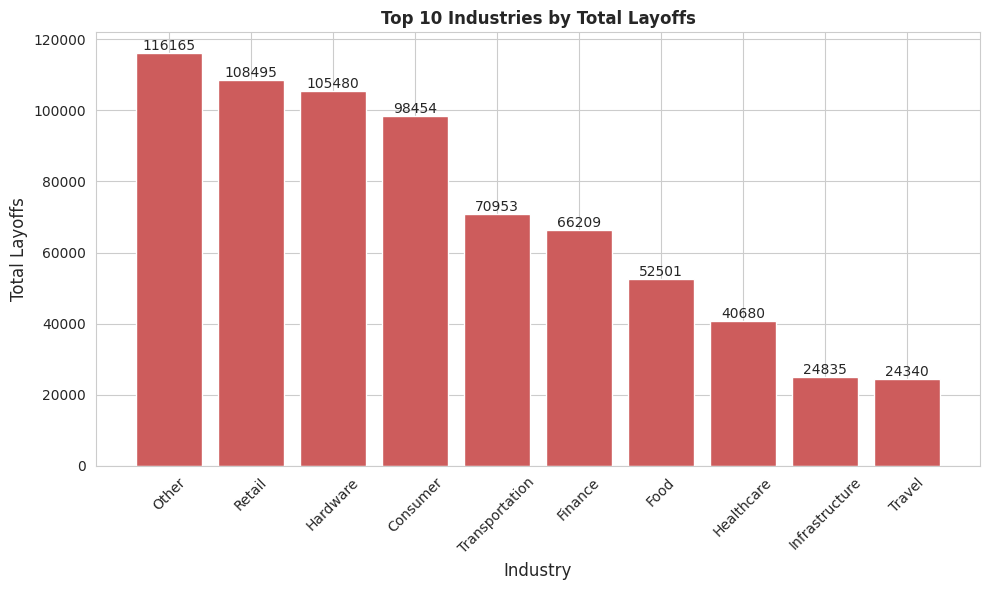

In [147]:
# Top 10 Industries by Layoff
plt.figure(figsize=(10, 6))# Seting the size of space of our graph
bar01 = plt.bar(by_industry.index[:10], by_industry.values[:10], color = 'indianred')# Making the graph
plt.bar_label(bar01, label_type= 'edge')# Putting values in the graph at the head of bars
plt.title('Top 10 Industries by Total Layoffs', fontweight = 'bold')
plt.xlabel('Industry', fontsize = 12)
plt.ylabel('Total Layoffs', fontsize = 12)
plt.xticks(rotation=45)# Rotating names of industries to make names readable
plt.tight_layout()
plt.show()

Categories of industries that combinedly fall into 'other' make up the most number of layoffs. Retail comes second after it.

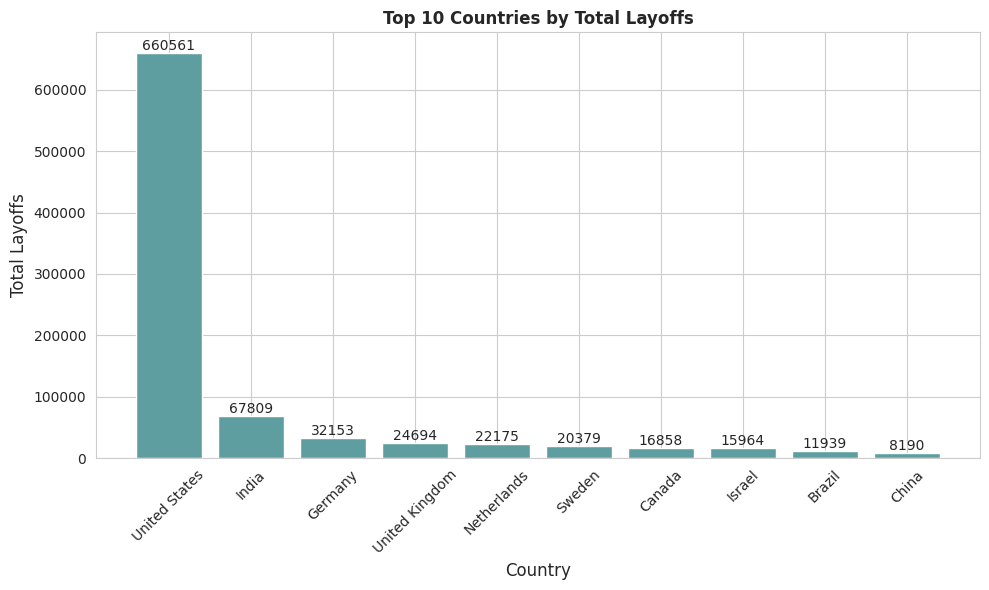

In [148]:
# Top 10 countries by layoffs
plt.figure(figsize=(10, 6))# Seting the size of space of our graph
bar02 = plt.bar(by_country.index[:10], by_country.values[:10], color = 'cadetblue')# Making the graph
plt.bar_label(bar02, label_type= 'edge')# Putting values in the graph at the head of bars
plt.title('Top 10 Countries by Total Layoffs', fontweight = 'bold')
plt.xlabel('Country', fontsize = 12)
plt.ylabel('Total Layoffs', fontsize = 12)
plt.xticks(rotation=45)# Rotating names of countries to make names readable
plt.tight_layout()
plt.show()

United Sates has the most layoffs. The magnitude of layoffs observed in the United States is so large that it outweighs the combined number of layoffs observed in other nine countries in top 10.  

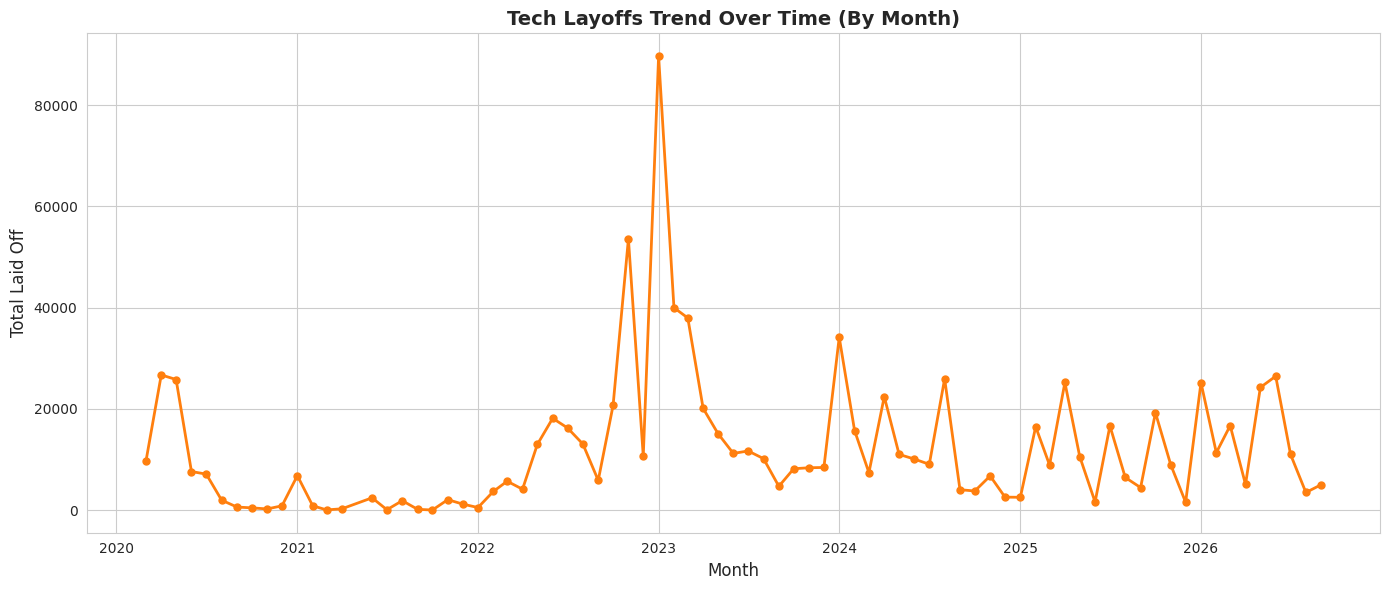

In [149]:
# Monthly trend of layoffs
plt.figure(figsize=(14, 6))
plt.plot(by_month.index, by_month.values, marker='o', color='tab:orange', linewidth=2, markersize=5)
plt.title("Tech Layoffs Trend Over Time (By Month)", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Laid Off", fontsize=12)
plt.tight_layout()
plt.show()

The most number of layoffs observed were those in the month January of 2023. It is also observed that more frequent layoff 'peaks' have occurred after 2023.

#5. Insights and Data Trustworthiness
1. **High-Confidence Finding:** The layoff trend reflects the real trend quite well; the reduction in layoffs following COVID-19, and rise in it after introduction of AI in working space.
2. **Data Caveat:** The 'percentage_laid_off' column still has some missing values.
3. **Business/Industry Takeaways:** While we see most of the layoffs occuring after intruduction of AI, and the United States observing most layoffs, there's a clear correlation suggesting that U.S. adapted inclusion of AI in work force the most.

#6. Bonus Mystery Question

In [157]:
# Group by company to aggregate total layoffs and max percentage laid off per company
company_summary = df.groupby('company').agg(
    total_laid_off=('total_laid_off', 'sum'),
    max_percentage=('percentage_laid_off', 'max')
).reset_index()

# 1. Look for complete shutdowns with small total numbers (High %, Low Total)
print("--- Complete Shutdowns with Small Total Numbers ---")
small_total_full_shutdown = company_summary[company_summary['max_percentage'] == 1.0].sort_values(by='total_laid_off', ascending=True)
display(small_total_full_shutdown.head(5))

# 2. Look for massive total layoffs with small percentages (High Total, Low %)
print("\n--- Massive Totals with Small Percentage Impact ---")
large_total_small_pct = company_summary.sort_values(by='total_laid_off', ascending=False)
display(large_total_small_pct.head(5))

--- Complete Shutdowns with Small Total Numbers ---


,company,total_laid_off,max_percentage
1280,Lido Learning,0.0,1.0
1459,Movement Labs,0.0,1.0
1468,Muni Tienda,0.0,1.0
1471,Muvin,0.0,1.0
1237,L1ght,0.0,1.0



--- Massive Totals with Small Percentage Impact ---


,company,total_laid_off,max_percentage
93,Amazon,59560.0,0.03
1124,Intel,43115.0,0.20
1410,Meta,35700.0,0.13
1417,Microsoft,34855.0,0.05
633,Dell,23650.0,0.10
